# Data Loading & Preprocessing

## data loading and EDA

In [4]:
import pandas as pd
import numpy as np

In [5]:
raw_data = pd.read_csv('../data/dsd_raw_sales_data.csv')
display(raw_data.head())

,Date,GuestCount
0,2021-08-01,119
1,2021-08-02,58
2,2021-08-03,52
3,2021-08-04,51
4,2021-08-05,79


In [7]:
new_data = pd.read_csv('../data/dsd_engineered_data.csv')
display(new_data.head())

,Date,DayOfWeek,IsWeekend,IsHoliday,Weather,Temperature,GuestCount
0,2021-08-01,6,1,0,Clear,31,119
1,2021-08-02,0,0,0,Clear,29,58
2,2021-08-03,1,0,0,Cloudy,29,52
3,2021-08-04,2,0,0,Cloudy,27,51
4,2021-08-05,3,0,0,Cloudy,27,79


In [8]:
print("Test Data Shape:", new_data.shape)

Test Data Shape: (1827, 7)


In [9]:
print("Train Data Types:", new_data.dtypes)

Train Data Types: Date             str
DayOfWeek      int64
IsWeekend      int64
IsHoliday      int64
Weather          str
Temperature    int64
GuestCount     int64
dtype: object


In [10]:
print("Train Data Missing values:", new_data.isnull().sum())

Train Data Missing values: Date           0
DayOfWeek      0
IsWeekend      0
IsHoliday      0
Weather        0
Temperature    0
GuestCount     0
dtype: int64


In [11]:
print("Train Data Duplicate values:", new_data.duplicated().sum())

Train Data Duplicate values: 0


In [14]:
!pip install matplotlib
!pip install seaborn

  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl (73 kB)
Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


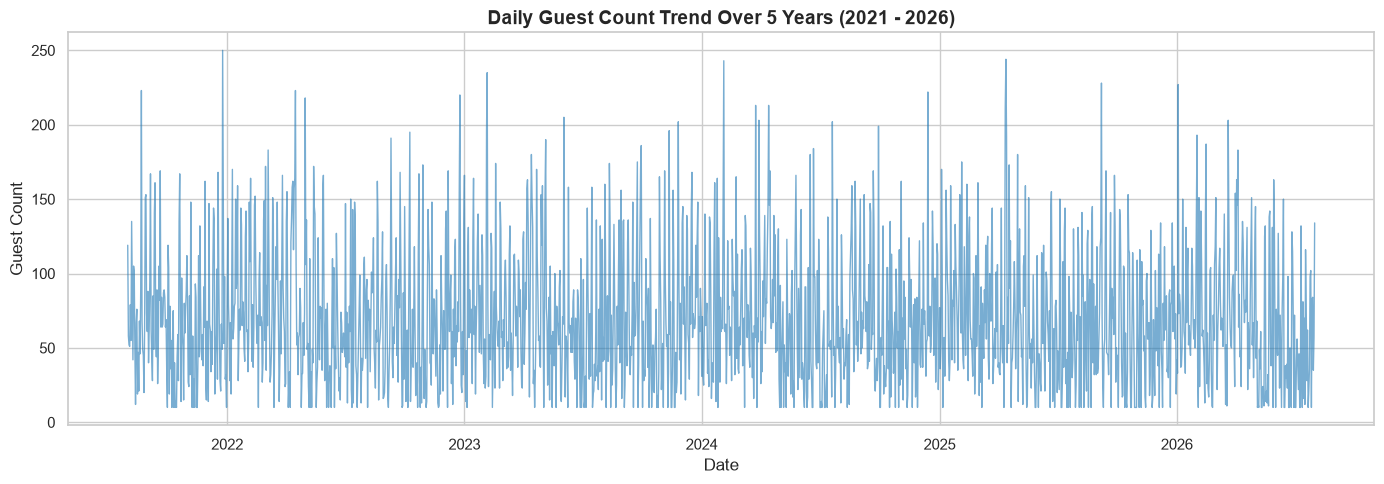

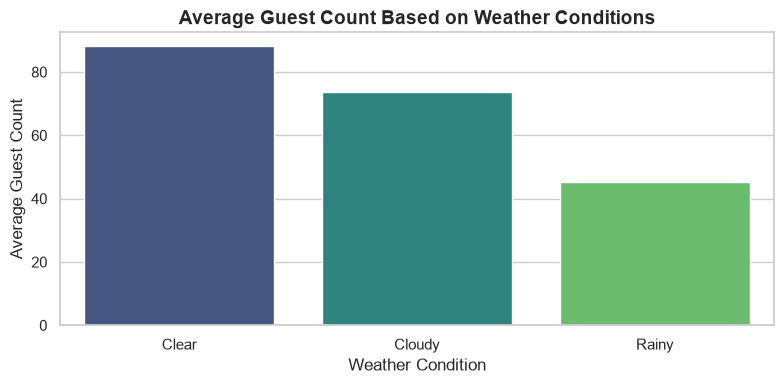

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 1. Time-Series Plot: Guest Count Trend over the 5 years
plt.figure(figsize=(14, 5))
plt.plot(pd.to_datetime(new_data['Date']), new_data['GuestCount'], color='#1f77b4', alpha=0.6, linewidth=1)
plt.title('Daily Guest Count Trend Over 5 Years (2021 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Guest Count', fontsize=12)
plt.tight_layout()
plt.show()

# 2. Bar Chart: Impact of Weather on Average Guest Count
plt.figure(figsize=(8, 4))
weather_avg = new_data.groupby('Weather')['GuestCount'].mean().reset_index()
sns.barplot(x='Weather', y='GuestCount', data=weather_avg, palette='viridis', hue='Weather', legend=False)
plt.title('Average Guest Count Based on Weather Conditions', fontsize=14, fontweight='bold')
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Average Guest Count', fontsize=12)
plt.tight_layout()
plt.show()

## preprocessing

In [12]:
# 1. One-Hot Encoding for categorical variables ('Weather')
encoded_data = pd.get_dummies(new_data, columns=['Weather'], dtype=int)

# 2. Drop the 'Date' column
encoded_data = encoded_data.drop(['Date'], axis=1)

# 3. Target & Feature Separation
X = encoded_data.drop(['GuestCount'], axis=1)

# y contains the target variable (the answer we want to predict)
y = encoded_data['GuestCount']

# Display the final features shape and a preview
print("Features (X) Shape:", X.shape)
display(X.head())

Features (X) Shape: (1827, 7)


,DayOfWeek,IsWeekend,IsHoliday,Temperature,Weather_Clear,Weather_Cloudy,Weather_Rainy
0,6,1,0,31,1,0,0
1,0,0,0,29,1,0,0
2,1,0,0,29,0,1,0
3,2,0,0,27,0,1,0
4,3,0,0,27,0,1,0


# Target & Feature Separation

# Train-Test Split

# Model selection, Training & testing

# Model Deployment